In [2]:
# calling database form csv

import pandas as pd
import sys, os
# sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))


db = pd.read_csv('../../data/database/database.csv')
db.head()

,TIME,DATE,TC_1,TC_2,TC_3,TC_4,TC_5,TC_6,TC_7,TC_8,...,P[bar],Te_mean[K],Tc_mean[K],Te_std[K],Tc_std[K],T_pulse[K],TR[K/W],GFE_Te[KJ/mol],GFE_Tc[KJ/mol],dG[KJ/mol]
0,19:02:43,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.42,307.43,303.97,273.51,274.64,353.75,0.09,-2232.13,-2207.04,-25.09
1,19:02:44,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.42,307.43,303.97,273.51,274.64,353.75,0.09,-2232.13,-2207.04,-25.09
2,19:02:46,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.42,307.43,303.97,273.51,274.64,353.75,0.09,-2232.13,-2207.04,-25.09
3,19:02:50,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.42,307.43,303.97,273.51,274.64,353.75,0.09,-2232.13,-2207.04,-25.09
4,19:02:53,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.43,307.43,303.97,273.51,274.64,353.75,0.09,-2172.41,-2147.99,-24.41


In [3]:
db.columns

Index(['TIME', 'DATE', 'TC_1', 'TC_2', 'TC_3', 'TC_4', 'TC_5', 'TC_6', 'TC_7',
       'TC_8', 'TC_9', 'PRESSURE', 'HEATER', 'HEATER SET POINT', 'date',
       'voltage', 'current', 'power', 'WF', 'FR[%]', 'Q[W]', 'alpha', 'beta',
       'pulse', 'Te_mean[C]', 'Tc_mean[C]', 'Te_std[C]', 'Tc_std[C]', 'P[bar]',
       'Te_mean[K]', 'Tc_mean[K]', 'Te_std[K]', 'Tc_std[K]', 'T_pulse[K]',
       'TR[K/W]', 'GFE_Te[KJ/mol]', 'GFE_Tc[KJ/mol]', 'dG[KJ/mol]'],
      dtype='object')

In [4]:
df_FR60_Q100 = db[(db['FR[%]'] == 60) & (db['Q[W]'] == 120)]
df_FR60_Q100

,TIME,DATE,TC_1,TC_2,TC_3,TC_4,TC_5,TC_6,TC_7,TC_8,...,P[bar],Te_mean[K],Tc_mean[K],Te_std[K],Tc_std[K],T_pulse[K],TR[K/W],GFE_Te[KJ/mol],GFE_Tc[KJ/mol],dG[KJ/mol]


In [5]:

# from zenml.client import Client

# artifact = Client().get_artifact_version('909b4d1a-4555-4310-92f4-3a213e7573b9')
# df = artifact.load()

In [6]:
df = db.copy()

Matplotlib is building the font cache; this may take a moment.


FR 60
Q 40
alpha 0, beta 0
Q 60
alpha 0, beta 0
Q 80
alpha 0, beta 0
Q 100
alpha 0, beta 0


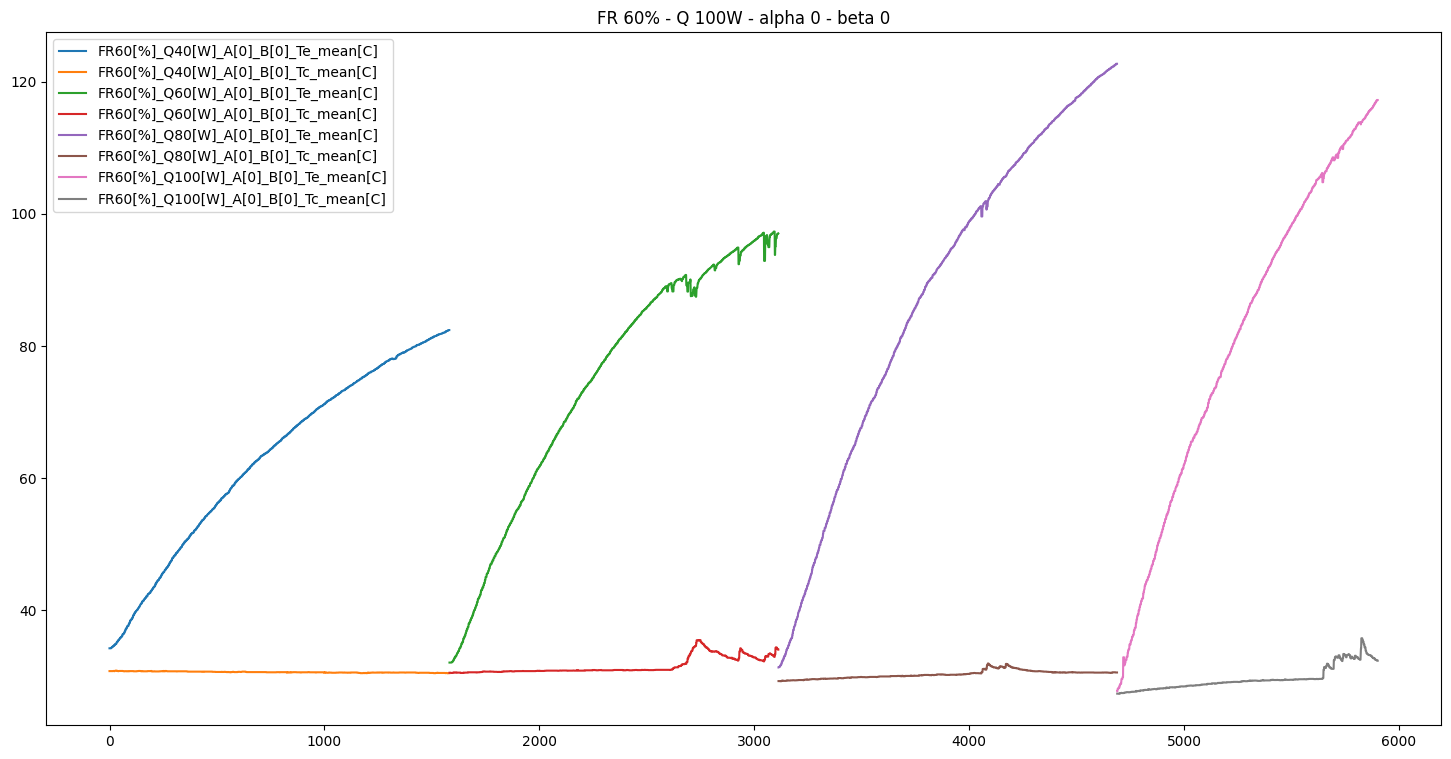

In [7]:
frs = df['FR[%]'].unique()
qs = df['Q[W]'].unique()
alphas = df['alpha'].unique()
betas = df['beta'].unique()
betas

import matplotlib.pyplot as plt

# Assuming frs, qs, alphas, betas are defined and df is your DataFrame
plt.figure(figsize=(18, 9))
for fr in frs:
    print(f'FR {fr}')
    for q in qs:
        print(f'Q {q}')
        for a in alphas:
            for b in betas:
                print(f'alpha {a}, beta {b}')
                
                # Filter the dataframe
                df_ = df[(df['FR[%]'] == fr) & (df['Q[W]'] == q) & (df['alpha'] == a) & (df['beta'] == b)]
                # df_.reset_index(inplace=True)
                
                if not df_.empty:
                    # Plotting
                    # plt.figure(figsize=(18, 6))
                    plt.plot(df_['Te_mean[C]'], label=f'FR{fr}[%]_Q{q}[W]_A[{a}]_B[{b}]_Te_mean[C]')
                    plt.plot(df_['Tc_mean[C]'], label=f'FR{fr}[%]_Q{q}[W]_A[{a}]_B[{b}]_Tc_mean[C]')
# change intend and it will change different overlapping of the graphs
plt.legend()
plt.title(f'FR {fr}% - Q {q}W - alpha {a} - beta {b}')
plt.show()


In [8]:
df

,TIME,DATE,TC_1,TC_2,TC_3,TC_4,TC_5,TC_6,TC_7,TC_8,...,P[bar],Te_mean[K],Tc_mean[K],Te_std[K],Tc_std[K],T_pulse[K],TR[K/W],GFE_Te[KJ/mol],GFE_Tc[KJ/mol],dG[KJ/mol]
0,19:02:43,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.42,307.43,303.97,273.51,274.64,353.75,0.09,-2232.13,-2207.04,-25.09
1,19:02:44,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.42,307.43,303.97,273.51,274.64,353.75,0.09,-2232.13,-2207.04,-25.09
2,19:02:46,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.42,307.43,303.97,273.51,274.64,353.75,0.09,-2232.13,-2207.04,-25.09
3,19:02:50,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.42,307.43,303.97,273.51,274.64,353.75,0.09,-2232.13,-2207.04,-25.09
4,19:02:53,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.43,307.43,303.97,273.51,274.64,353.75,0.09,-2172.41,-2147.99,-24.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5897,14:59:05,21/11/2024,117.3,117.0,116.9,118.3,116.6,36.1,32.1,33.3,...,0.62,390.37,305.65,273.80,276.30,379.33,0.85,-1577.74,-1235.33,-342.41
5898,14:59:07,21/11/2024,117.3,117.0,116.9,118.3,116.6,35.9,32.0,33.3,...,0.62,390.37,305.55,273.80,276.27,379.33,0.85,-1577.74,-1234.92,-342.81
5899,14:59:08,21/11/2024,117.3,117.0,116.9,118.3,116.6,35.9,32.0,33.3,...,0.62,390.37,305.55,273.80,276.27,379.33,0.85,-1577.74,-1234.92,-342.81
5900,14:59:09,21/11/2024,117.3,117.0,116.9,118.3,116.6,35.9,32.0,33.3,...,0.62,390.37,305.55,273.80,276.27,379.33,0.85,-1577.74,-1234.92,-342.81


In [9]:
df.select_dtypes(include='object').columns.to_list()

['TIME', 'DATE', 'date', 'WF', 'pulse']

In [10]:
# Ensure Te_mean[C] and Tc_mean[C] are numeric
df['Te_mean[C]'] = pd.to_numeric(df['Te_mean[C]'], errors='coerce')
df['Tc_mean[C]'] = pd.to_numeric(df['Tc_mean[C]'], errors='coerce')

# Identify the object column automatically
object_column = df.select_dtypes(include='object').columns

# df_n = df.drop(columns=df.select_dtypes(include='object').columns, inplace=True)


# # Group by 'Te_mean[C]' and calculate the mean of numeric columns
df_numeric_mean = df.drop(columns=object_column)\
                    .groupby('Te_mean[C]')\
                    .agg('mean')

# # Extract the first value of the identified object column for each group
df_object = df.groupby('Te_mean[C]')[object_column].first()

# # Combine the mean numeric columns with the object column
df_mean = pd.concat([df_numeric_mean, df_object], axis=1).reset_index()
# df.drop(columns=df.select_dtypes(include='object').columns, inplace=True)
# # df.reset_index(inplace=True)
# df_mean = df.sort_values('Te_mean[C]').groupby(['Te_mean[C]'], as_index=False).mean()

df_mean

,Te_mean[C],TC_1,TC_2,TC_3,TC_4,TC_5,TC_6,TC_7,TC_8,TC_9,...,T_pulse[K],TR[K/W],GFE_Te[KJ/mol],GFE_Tc[KJ/mol],dG[KJ/mol],TIME,DATE,date,WF,pulse
0,27.78,27.4,28.2,27.7,27.7,27.9,27.900000,27.700000,27.700000,26.400000,...,379.33,0.00,-2499.660,-2496.710000,-2.950000,14:18:28,21/11/2024,2024-11-21 14:18:28,DI water,14:50:10
1,28.14,27.8,28.6,28.0,28.1,28.2,27.975000,27.625000,27.700000,26.400000,...,379.33,0.01,-2553.710,-2547.650000,-6.060000,14:18:31,21/11/2024,2024-11-21 14:18:31,DI water,14:50:10
2,28.32,28.0,28.8,28.2,28.3,28.3,27.920000,27.600000,27.700000,26.400000,...,379.33,0.01,-2531.394,-2523.714000,-7.682000,14:18:38,21/11/2024,2024-11-21 14:18:38,DI water,14:50:10
3,28.68,28.4,29.2,28.6,28.6,28.6,27.966667,27.666667,27.766667,26.466667,...,379.33,0.01,-2462.880,-2452.976667,-9.903333,14:18:45,21/11/2024,2024-11-21 14:18:45,DI water,14:50:10
4,28.90,28.6,29.4,28.8,28.9,28.8,28.000000,27.700000,27.800000,26.500000,...,379.33,0.01,-2550.274,-2538.458000,-11.824000,14:18:50,21/11/2024,2024-11-21 14:18:50,DI water,14:50:10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1613,122.30,122.4,122.2,122.1,123.2,121.6,31.400000,31.200000,31.300000,28.700000,...,327.27,1.15,-1908.058,-1465.842000,-442.212000,15:44:24,15/09/2024,2024-09-15 15:44:24,DI water,15:10:08
1614,122.44,122.6,122.4,122.1,123.4,121.7,31.400000,31.200000,31.300000,28.700000,...,327.27,1.15,-1912.590,-1468.806667,-443.783333,15:44:34,15/09/2024,2024-09-15 15:44:34,DI water,15:10:08
1615,122.48,122.6,122.4,122.2,123.4,121.8,31.400000,31.200000,31.300000,28.700000,...,327.27,1.15,-1932.090,-1483.630000,-448.460000,15:44:40,15/09/2024,2024-09-15 15:44:40,DI water,15:10:08
1616,122.60,122.7,122.5,122.4,123.6,121.8,31.400000,31.200000,31.300000,28.600000,...,327.27,1.15,-1932.680,-1483.510000,-449.170000,15:44:47,15/09/2024,2024-09-15 15:44:47,DI water,15:10:08


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5902 entries, 0 to 5901
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TIME              5902 non-null   object 
 1   DATE              5902 non-null   object 
 2   TC_1              5902 non-null   float64
 3   TC_2              5902 non-null   float64
 4   TC_3              5902 non-null   float64
 5   TC_4              5902 non-null   float64
 6   TC_5              5902 non-null   float64
 7   TC_6              5902 non-null   float64
 8   TC_7              5902 non-null   float64
 9   TC_8              5902 non-null   float64
 10  TC_9              5902 non-null   float64
 11  PRESSURE          5902 non-null   float64
 12  HEATER            5902 non-null   int64  
 13  HEATER SET POINT  5902 non-null   int64  
 14  date              5902 non-null   object 
 15  voltage           5902 non-null   float64
 16  current           5902 non-null   float64


In [12]:
# df_mean = df.sort_values('Te_mean[C]').groupby(['Te_mean[C]'], as_index=False).mean()
# df_mean

FR 60
Q 40
alpha 0, beta 0


<Figure size 1800x900 with 0 Axes>

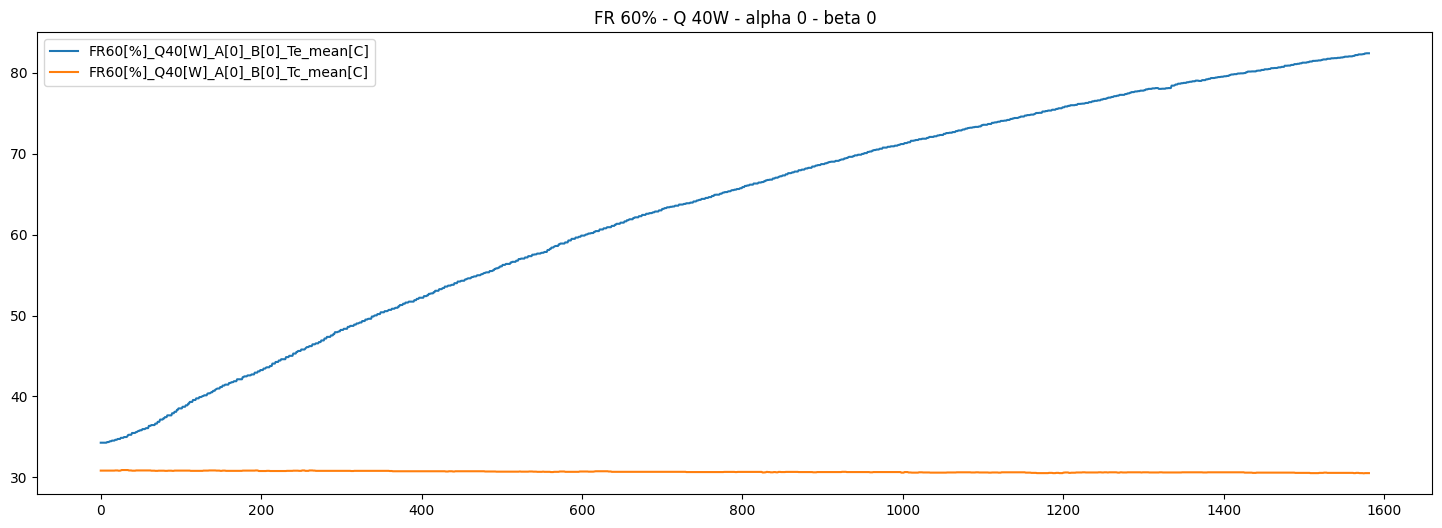

Q 60
alpha 0, beta 0


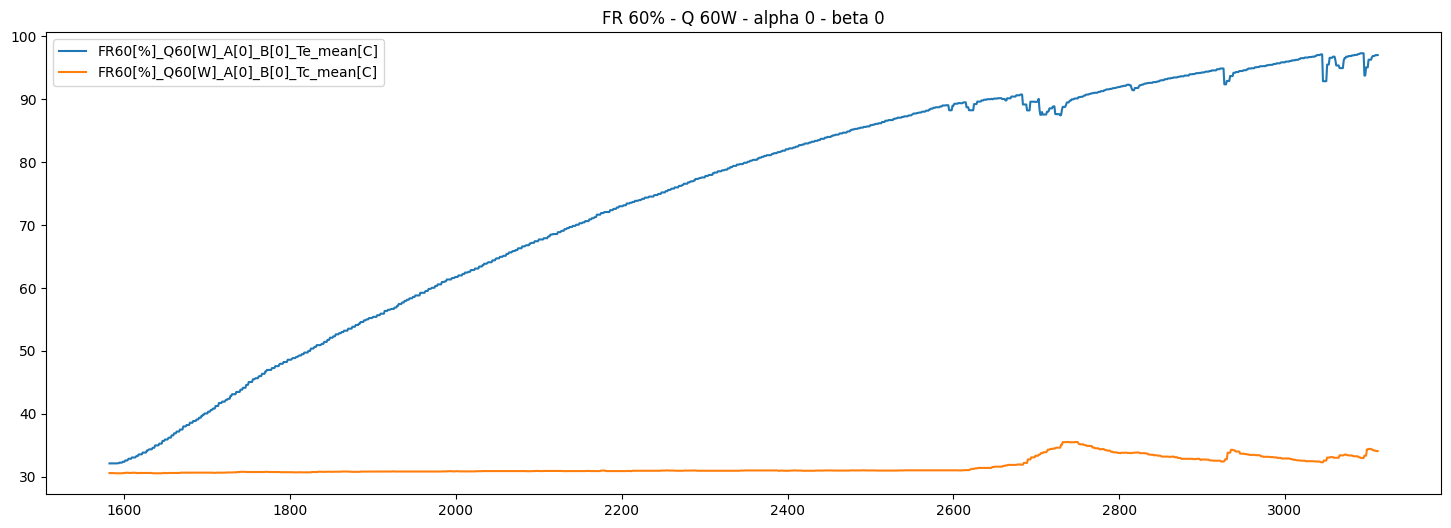

Q 80
alpha 0, beta 0


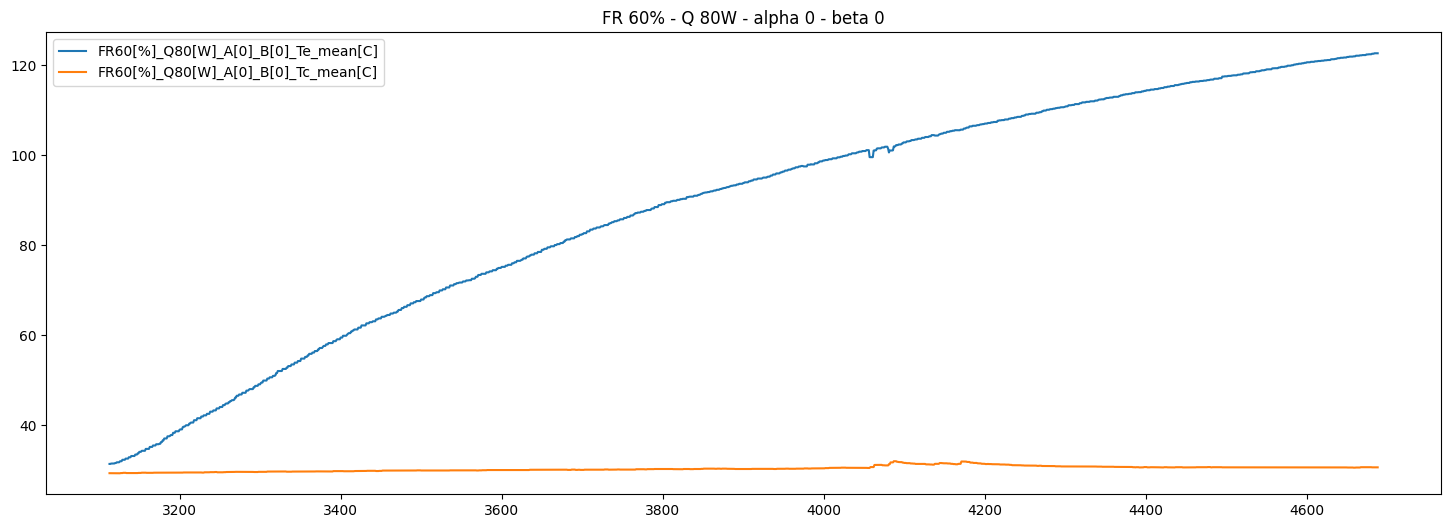

Q 100
alpha 0, beta 0


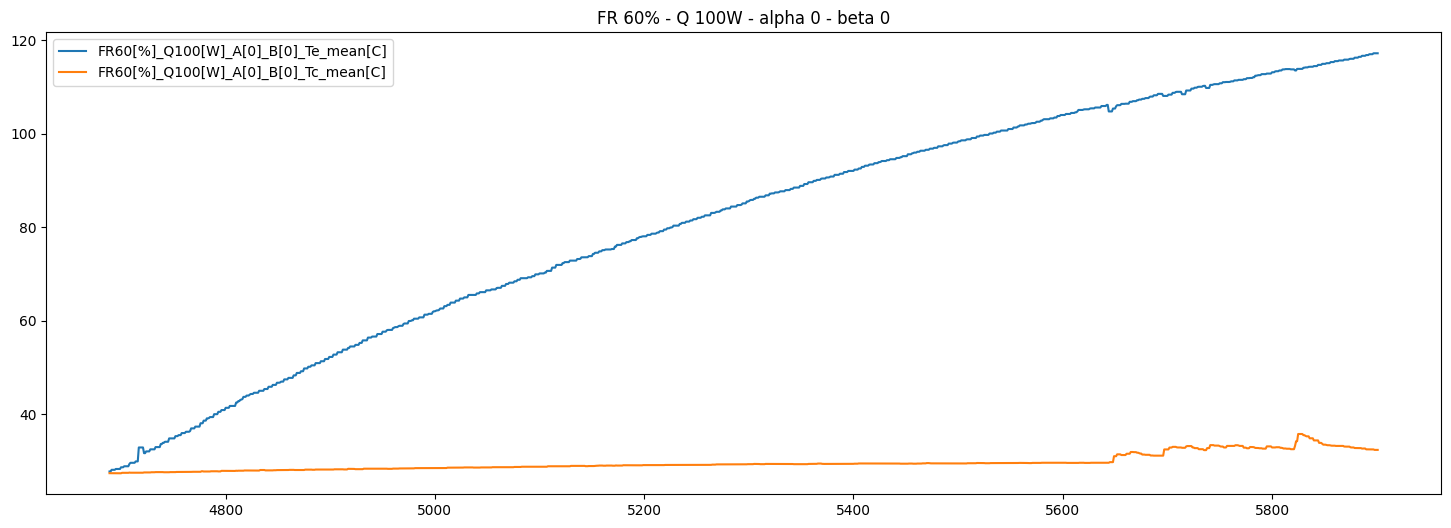

In [13]:
import matplotlib.pyplot as plt

# Assuming frs, qs, alphas, betas are defined and df is your DataFrame
plt.figure(figsize=(18, 9))
for fr in frs:
    print(f'FR {fr}')
    for q in qs:
        print(f'Q {q}')
        for a in alphas:
            for b in betas:
                print(f'alpha {a}, beta {b}')
                
                # Filter the dataframe
                df_ = df[(df['FR[%]'] == fr) & (df['Q[W]'] == q) & (df['alpha'] == a) & (df['beta'] == b)]
                
                if not df_.empty:
                    # Plotting
                    plt.figure(figsize=(18, 6))
                    plt.plot(df_['Te_mean[C]'], label=f'FR{fr}[%]_Q{q}[W]_A[{a}]_B[{b}]_Te_mean[C]')
                    plt.plot(df_['Tc_mean[C]'], label=f'FR{fr}[%]_Q{q}[W]_A[{a}]_B[{b}]_Tc_mean[C]')
                    plt.legend()
                    plt.title(f'FR {fr}% - Q {q}W - alpha {a} - beta {b}')
                    plt.show()


In [14]:
import pygwalker as pyg
from pygwalker.api.streamlit import StreamlitRenderer
import streamlit as st
from streamlit.components.v1 import components

2025-09-25 19:31:01.068 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [15]:
df['TIME'] = pd.to_datetime(df['TIME'], format='%H:%M:%S')

In [16]:
st.set_page_config(page_title='Pulsating Heat Pipe - Data Visualization Dash-Board',)
st.title('PHP')

pyg_html = pyg.walk(dataset=df, return_html=True)


2025-09-25 19:31:01.263 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-25 19:31:01.271 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-25 19:31:01.411 
  command:

    streamlit run g:\Kamlesh\php_pulsating_heat_pipe\Krp_Analysis\Advanced_PulseHeatPipe_krp\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-09-25 19:31:01.411 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-25 19:31:01.411 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Box(children=(HTML(value='\n<div id="ifr-pyg-00063fa0996aa2d07bBFUwjtzNOQScEH" style="height: auto">\n    <hea…

FR 60
Q 40
alpha 0, beta 0


<Figure size 1800x900 with 0 Axes>

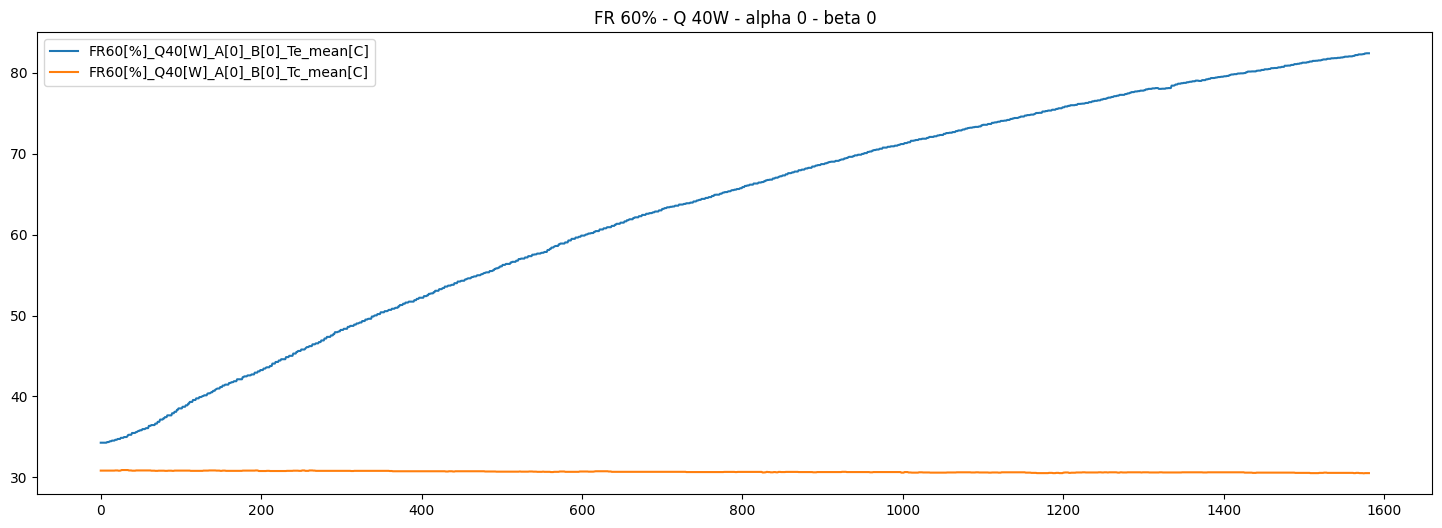

Q 60
alpha 0, beta 0


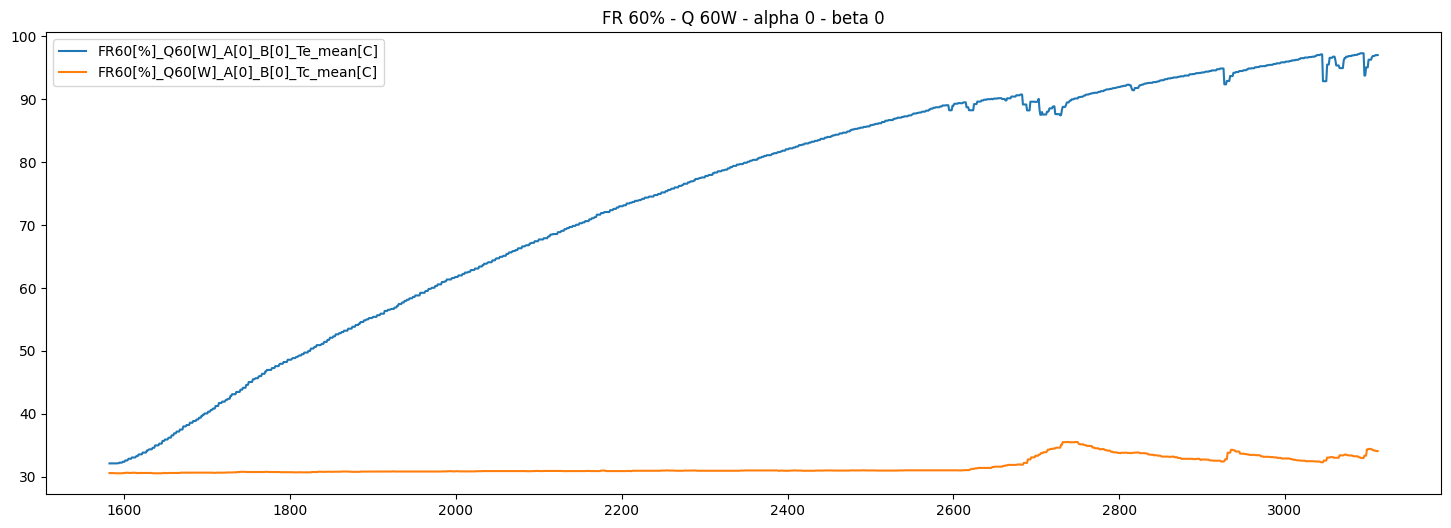

Q 80
alpha 0, beta 0


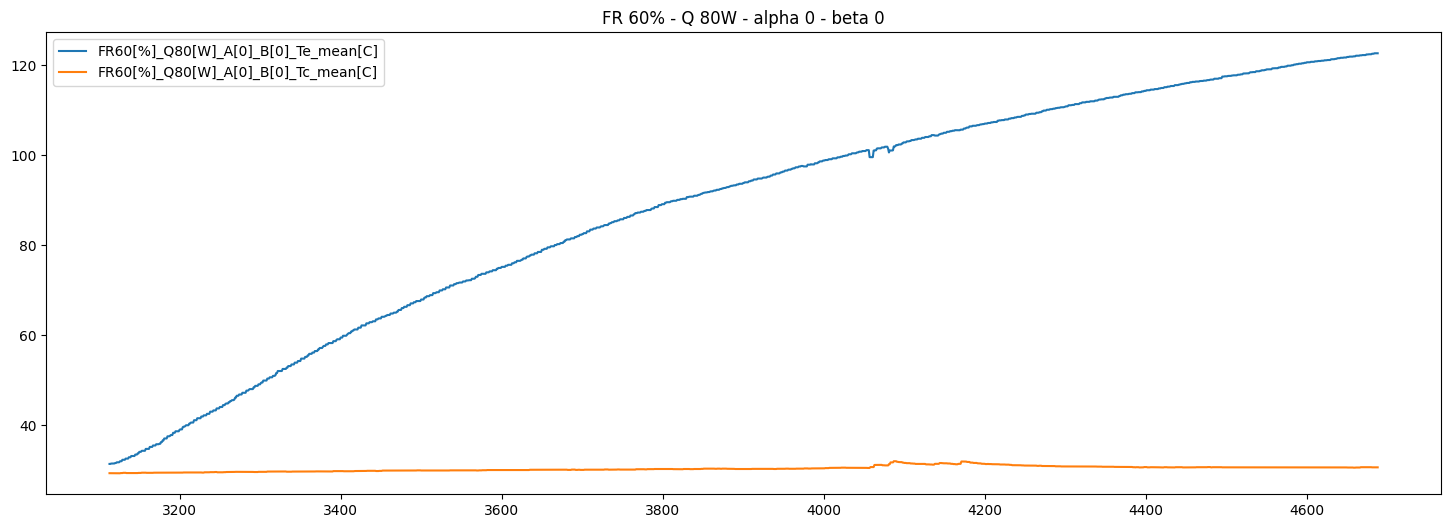

Q 100
alpha 0, beta 0


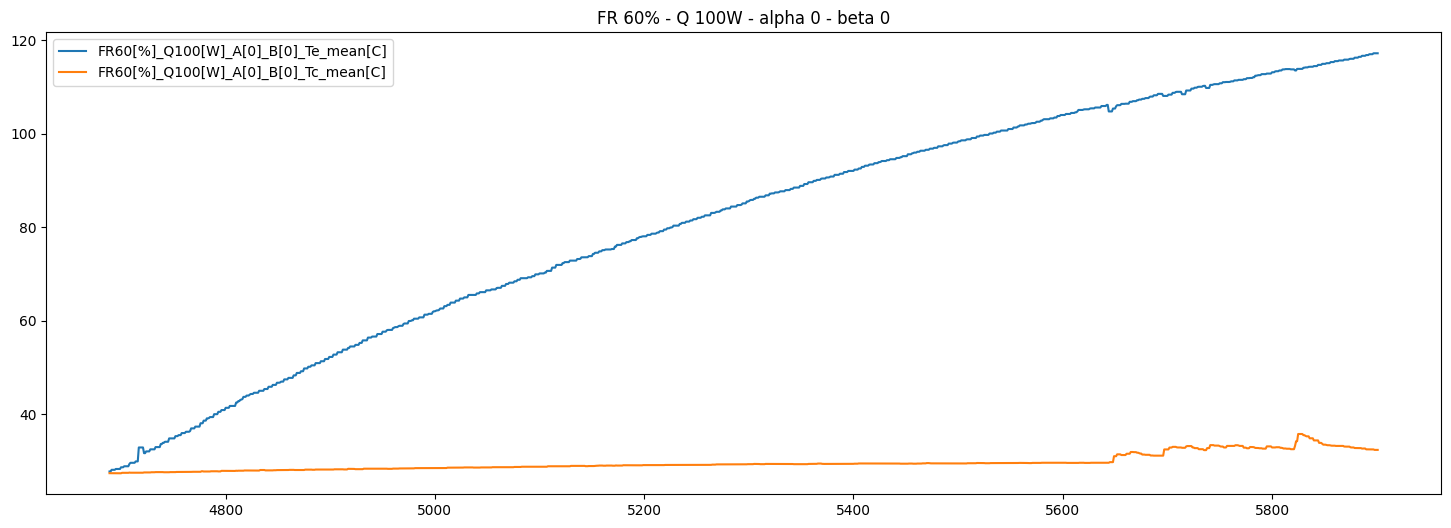

In [17]:
import matplotlib.pyplot as plt

# Assuming frs, qs, alphas, betas are defined and df is your DataFrame
plt.figure(figsize=(18, 9))
for fr in frs:
    print(f'FR {fr}')
    for q in qs:
        print(f'Q {q}')
        for a in alphas:
            for b in betas:
                print(f'alpha {a}, beta {b}')
                
                # Filter the dataframe
                df_ = df[(df['FR[%]'] == fr) & (df['Q[W]'] == q) & (df['alpha'] == a) & (df['beta'] == b)]
                
                if not df_.empty:
                    # Plotting
                    plt.figure(figsize=(18, 6))
                    plt.plot(df_['Te_mean[C]'], label=f'FR{fr}[%]_Q{q}[W]_A[{a}]_B[{b}]_Te_mean[C]')
                    plt.plot(df_['Tc_mean[C]'], label=f'FR{fr}[%]_Q{q}[W]_A[{a}]_B[{b}]_Tc_mean[C]')
                    plt.legend()
                    plt.title(f'FR {fr}% - Q {q}W - alpha {a} - beta {b}')
                    plt.show()


In [18]:
pulse_time = db['pulse'].unique()

In [19]:
for time in pulse_time:
    db_pt = db[db['TIME']==time]
    Te_pt = db_pt['Te_mean[K]'].min()
    Tc_pt = db_pt['Tc_mean[K]'].min()
    print(Te_pt, Tc_pt)

353.75 303.72
352.85 304.12
327.27 303.22
379.33 302.8


In [20]:
db['pulse'] = pd.to_datetime(db['pulse'])
db['TIME'] = pd.to_datetime(db['TIME'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_11884\3001641875.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  db['pulse'] = pd.to_datetime(db['pulse'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_11884\3001641875.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  db['TIME'] = pd.to_datetime(db['TIME'])


In [21]:
db

,TIME,DATE,TC_1,TC_2,TC_3,TC_4,TC_5,TC_6,TC_7,TC_8,...,P[bar],Te_mean[K],Tc_mean[K],Te_std[K],Tc_std[K],T_pulse[K],TR[K/W],GFE_Te[KJ/mol],GFE_Tc[KJ/mol],dG[KJ/mol]
0,2025-09-25 19:02:43,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.42,307.43,303.97,273.51,274.64,353.75,0.09,-2232.13,-2207.04,-25.09
1,2025-09-25 19:02:44,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.42,307.43,303.97,273.51,274.64,353.75,0.09,-2232.13,-2207.04,-25.09
2,2025-09-25 19:02:46,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.42,307.43,303.97,273.51,274.64,353.75,0.09,-2232.13,-2207.04,-25.09
3,2025-09-25 19:02:50,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.42,307.43,303.97,273.51,274.64,353.75,0.09,-2232.13,-2207.04,-25.09
4,2025-09-25 19:02:53,27/03/2025,34.1,34.8,33.9,34.1,34.5,31.8,31.4,31.5,...,0.43,307.43,303.97,273.51,274.64,353.75,0.09,-2172.41,-2147.99,-24.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5897,2025-09-25 14:59:05,21/11/2024,117.3,117.0,116.9,118.3,116.6,36.1,32.1,33.3,...,0.62,390.37,305.65,273.80,276.30,379.33,0.85,-1577.74,-1235.33,-342.41
5898,2025-09-25 14:59:07,21/11/2024,117.3,117.0,116.9,118.3,116.6,35.9,32.0,33.3,...,0.62,390.37,305.55,273.80,276.27,379.33,0.85,-1577.74,-1234.92,-342.81
5899,2025-09-25 14:59:08,21/11/2024,117.3,117.0,116.9,118.3,116.6,35.9,32.0,33.3,...,0.62,390.37,305.55,273.80,276.27,379.33,0.85,-1577.74,-1234.92,-342.81
5900,2025-09-25 14:59:09,21/11/2024,117.3,117.0,116.9,118.3,116.6,35.9,32.0,33.3,...,0.62,390.37,305.55,273.80,276.27,379.33,0.85,-1577.74,-1234.92,-342.81
